## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

#from neuro_fuzzy_toolbox import h_ANFIS, Gaussian_MF
from neuro_fuzzy_toolbox import *

## Data

In [2]:
x_train = 2 * torch.rand(200, 3) - 1
x_train

tensor([[ 0.2160, -0.4544,  0.9902],
        [-0.8656, -0.6440, -0.2770],
        [ 0.0219,  0.2378, -0.0461],
        [ 0.9092, -0.3747,  0.7168],
        [ 0.5139, -0.6080,  0.0096],
        [ 0.1410,  0.9703,  0.2718],
        [ 0.3968,  0.2184, -0.2300],
        [ 0.7080, -0.3403, -0.4751],
        [-0.8897, -0.5363, -0.6918],
        [ 0.0639, -0.1763, -0.7740],
        [-0.6000, -0.8669, -0.4695],
        [-0.9613, -0.4109,  0.3688],
        [-0.1443, -0.9385, -0.0194],
        [-0.4447, -0.5850,  0.9499],
        [ 0.8841,  0.0621,  0.9860],
        [ 0.7796, -0.1013,  0.8558],
        [-0.8495, -0.6215,  0.6214],
        [-0.4868, -0.6071, -0.0761],
        [-0.8755,  0.3517, -0.9402],
        [ 0.9801,  0.9553, -0.2963],
        [-0.1866,  0.0087,  0.7554],
        [ 0.1527, -0.7465, -0.0515],
        [-0.0525,  0.3198,  0.0482],
        [-0.3638,  0.4946,  0.9648],
        [-0.4105,  0.0132,  0.7649],
        [-0.4447,  0.1238, -0.6295],
        [-0.5178,  0.6511, -0.8284],
 

## Model

In [3]:
model = h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=Gaussian_MF, # Función de membresía gaussiana
    output_type='regression', # Tipo de salida: regresión
)

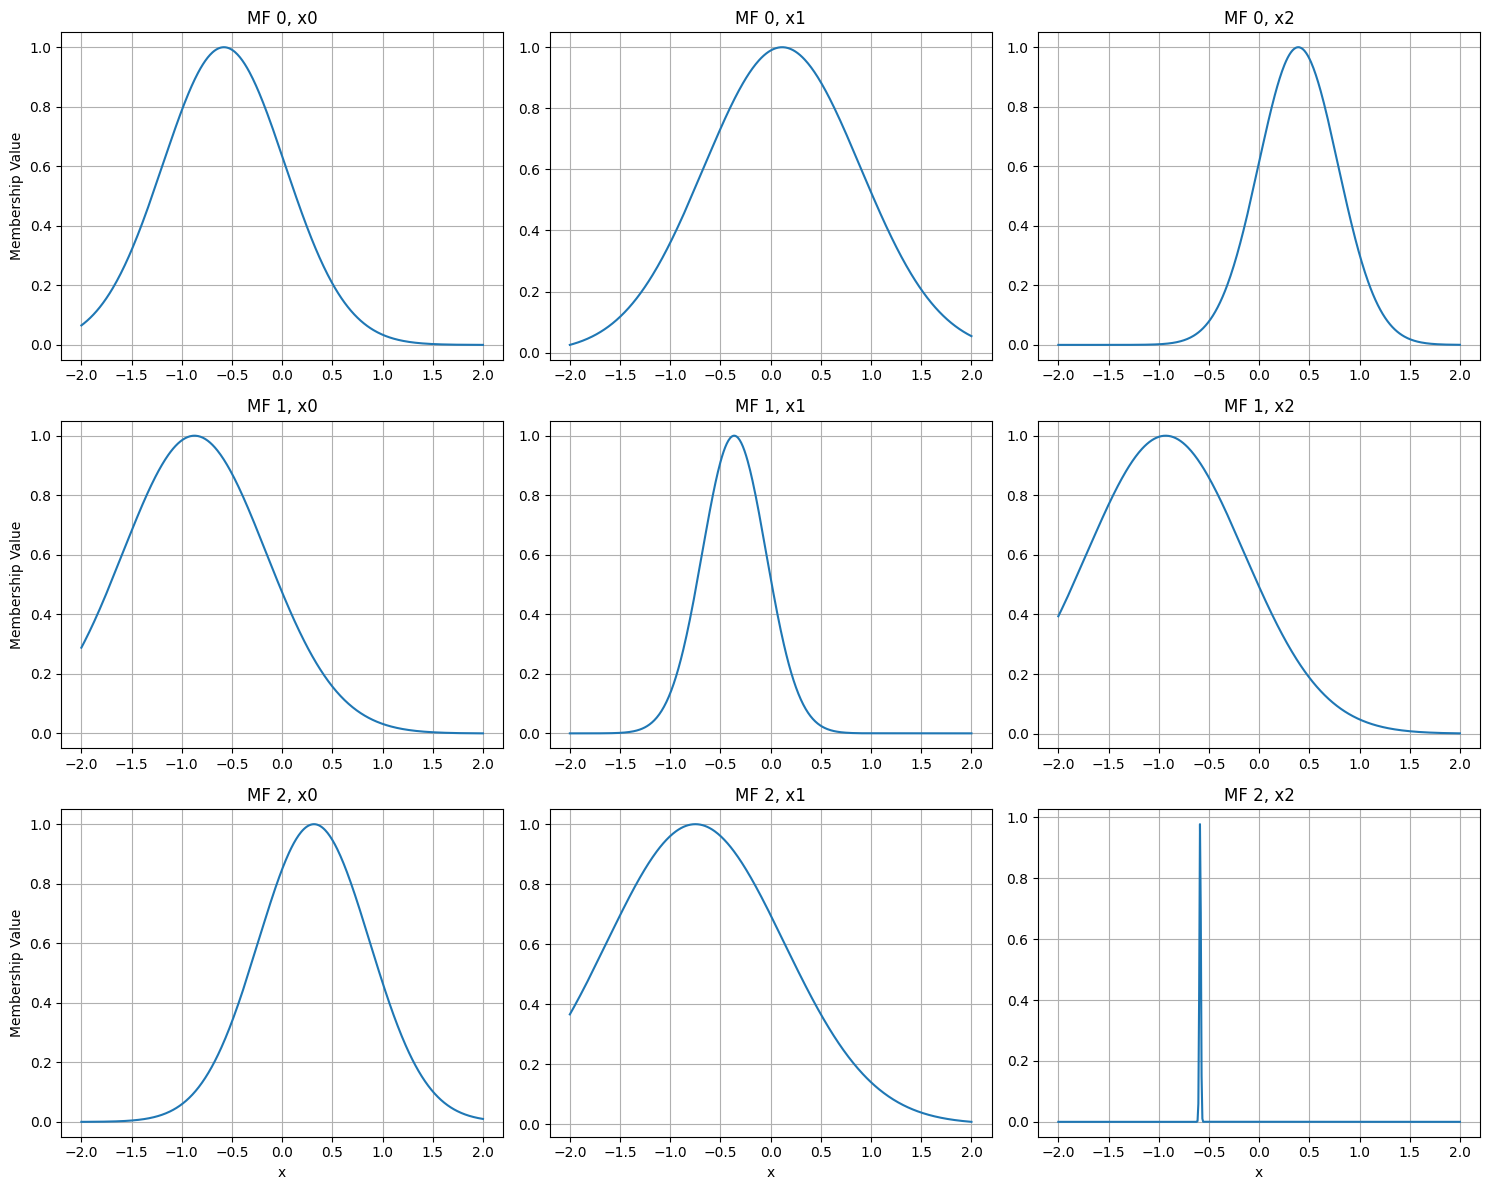

In [4]:
model.plot_premises()

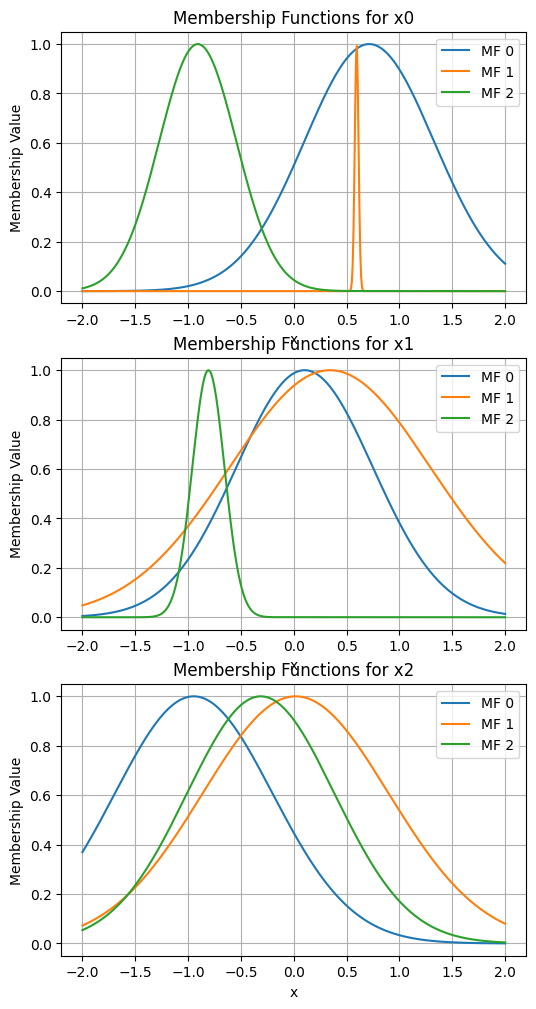

In [5]:
model.plot_premises(group_by_dim=True)

In [6]:
model.init_premises(x_train)

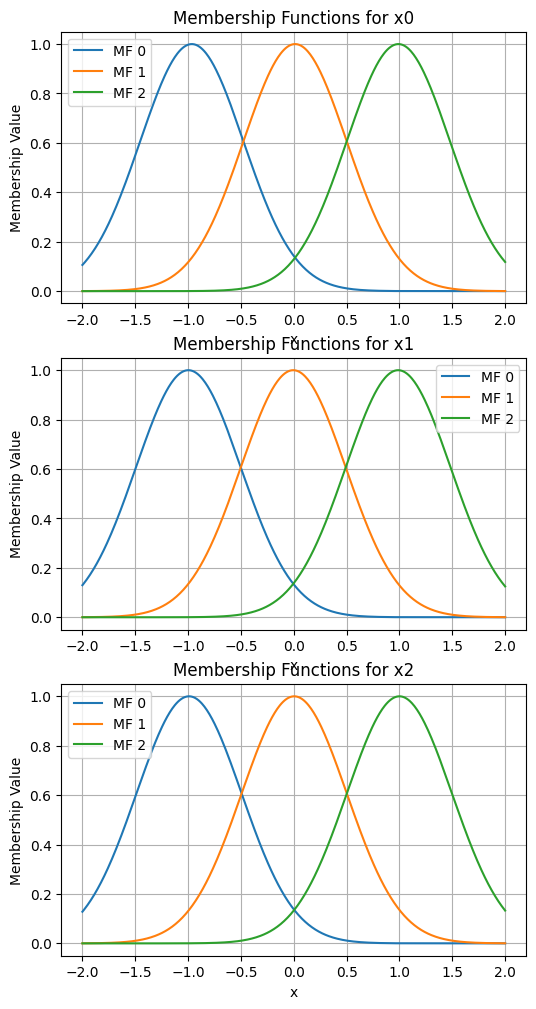

In [7]:
model.plot_premises(group_by_dim=True)

In [8]:
model.show_premises_structure()

       mu (x0)  sigma (x0)   mu (x1)  sigma (x1)   mu (x2)  sigma (x2)
MF 0 -0.964733    0.488651 -0.997156    0.496207 -0.991029    0.497705
MF 1  0.012570    0.488651 -0.004742    0.496207  0.004381    0.497705
MF 2  0.989873    0.488651  0.987672    0.496207  0.999791    0.497705


In [9]:
model.premises_structure

,mu (x0),sigma (x0),mu (x1),sigma (x1),mu (x2),sigma (x2)
MF 0,-0.964733,0.488651,-0.997156,0.496207,-0.991029,0.497705
MF 1,0.012570,0.488651,-0.004742,0.496207,0.004381,0.497705
MF 2,0.989873,0.488651,0.987672,0.496207,0.999791,0.497705


In [10]:
model.get_premises()

tensor([[[-0.9647,  0.4887],
         [ 0.0126,  0.4887],
         [ 0.9899,  0.4887]],

        [[-0.9972,  0.4962],
         [-0.0047,  0.4962],
         [ 0.9877,  0.4962]],

        [[-0.9910,  0.4977],
         [ 0.0044,  0.4977],
         [ 0.9998,  0.4977]]])

In [11]:
model.show_consequents_structure()

- Output 1:
          c0 (x0)   c1 (x1)   c2 (x2)        c3
rule 1  -0.826918 -0.414105 -0.704900 -0.911405
rule 2   0.966162 -0.621783  0.623495 -0.690875
rule 3   0.594605 -0.423835 -0.485354  0.980036
rule 4  -0.317451  0.331790  0.890660  0.332317
rule 5  -0.351951 -0.268445 -0.121083 -0.204730
rule 6  -0.249277 -0.167620 -0.501073 -0.569007
rule 7  -0.008962 -0.414586  0.520986  0.059063
rule 8   0.310283  0.730014  0.822216 -0.261765
rule 9   0.377173 -0.891877  0.924340  0.133996
rule 10  0.290779 -0.946463  0.367891 -0.352938
rule 11 -0.389940  0.921208 -0.213222  0.794469
rule 12  0.444370  0.689864 -0.447441  0.842136
rule 13 -0.630151  0.578169 -0.457253  0.681228
rule 14 -0.328824 -0.332286  0.751661 -0.099239
rule 15  0.007848 -0.497151  0.780458 -0.766015
rule 16 -0.437665  0.715503  0.378287  0.204300
rule 17  0.396210  0.762639 -0.792843  0.694822
rule 18 -0.177802  0.447422 -0.028460 -0.341650
rule 19 -0.229190 -0.136132 -0.370707 -0.267686
rule 20 -0.877061 -0.491921 

In [12]:
model(x_train[:10])

tensor([-0.2360, -0.0942, -0.2735, -0.1964,  0.1086, -0.0032,  0.0341,  0.0276,
         0.0334,  0.0410], grad_fn=<SqueezeBackward1>)

In [13]:
with torch.no_grad():
    output = model(x_train[:10])

print(output)

tensor([-0.2360, -0.0942, -0.2735, -0.1964,  0.1086, -0.0032,  0.0341,  0.0276,
         0.0334,  0.0410])


In [14]:
model.predict(x_train[:10])

array([-0.236038  , -0.09418173, -0.27348295, -0.19640984,  0.10858376,
       -0.00324795,  0.03409334,  0.02759202,  0.03338641,  0.04100133],
      dtype=float32)

## Binary output

In [15]:
x_train = 2 * torch.rand(200, 3) - 1

In [16]:
bin_model = h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=Gaussian_MF, # Función de membresía gaussiana
    output_type='binary', # Tipo de salida: clasificación binaria
)

In [17]:
bin_model.predict(x_train[:10])

array([1, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [18]:
bin_model(x_train[:10])

tensor([0.5150, 0.4718, 0.5816, 0.4319, 0.4855, 0.7345, 0.6815, 0.5022, 0.6042,
        0.5569], grad_fn=<SigmoidBackward0>)

## Multiple outputs

In [19]:
x_train = 2 * torch.rand(200, 2) - 1

In [20]:
model = h_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=2, # 2 salidas
    membership_function=Gaussian_MF, # Función de membresía gaussiana
    output_type='regression', # Tipo de salida: regresión
)

In [21]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1  0.838559  0.792529  0.334557
rule 2 -0.698886 -0.836338  0.570463
rule 3 -0.921845  0.920163 -0.339682
rule 4  0.090951 -0.258304 -0.457782
rule 5  0.278434 -0.151923 -0.633386
rule 6 -0.825580 -0.930840 -0.957051
rule 7 -0.604793  0.390918  0.201622
rule 8  0.057745 -0.346415 -0.462658
rule 9  0.176575  0.898998 -0.807791


- Output 2:
         c0 (x0)   c1 (x1)        c2
rule 1  0.441311 -0.169723  0.267101
rule 2 -0.360269  0.974579 -0.207885
rule 3 -0.532582 -0.634973  0.830583
rule 4 -0.264511 -0.230147  0.547065
rule 5 -0.425836  0.587975  0.500229
rule 6 -0.476827  0.392123 -0.106767
rule 7 -0.623033  0.880447  0.371699
rule 8 -0.314601  0.541882 -0.442709
rule 9  0.687217 -0.549018  0.993765




In [22]:
model(x_train[:10])

tensor([[ 0.1501,  0.5325],
        [-0.3426,  0.3519],
        [ 0.4363,  0.2840],
        [-0.0889,  0.5314],
        [ 0.3663,  0.5264],
        [-0.2340,  0.3426],
        [-0.1653,  0.5659],
        [ 0.2062,  0.3888],
        [ 0.4797,  0.5082],
        [-0.5938,  0.0508]], grad_fn=<SqueezeBackward1>)

## Multiclass problem

In [23]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

model = h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=2, # 2 funciones de membresía
    outputs=3, # 3 salidas
    membership_function=Gaussian_MF, # Función de membresía gaussiana
    output_type='multiclass', # Tipo de salida: clasificación multiclase
)

In [24]:
model(x_train[:10])

tensor([[-0.5759,  0.9541,  0.2970],
        [-0.2917,  0.4547, -0.9439],
        [ 0.5124, -0.6826, -0.3454],
        [-0.8390,  0.9174, -0.9471],
        [-0.9870,  1.0792, -0.8661],
        [-1.7170,  1.9342, -0.3654],
        [-0.0322,  0.5905,  0.7484],
        [ 0.1828, -0.0688, -1.1221],
        [-0.4592,  0.7823, -0.2416],
        [-0.3206,  0.5607, -0.6278]], grad_fn=<SqueezeBackward1>)

In [25]:
model(x_train[:10], return_probabilities=True)

tensor([[0.1248, 0.5764, 0.2988],
        [0.2755, 0.5811, 0.1435],
        [0.5791, 0.1753, 0.2456],
        [0.1301, 0.7532, 0.1167],
        [0.0998, 0.7876, 0.1126],
        [0.0231, 0.8879, 0.0891],
        [0.1981, 0.3693, 0.4325],
        [0.4881, 0.3795, 0.1324],
        [0.1753, 0.6067, 0.2179],
        [0.2410, 0.5817, 0.1772]], grad_fn=<SoftmaxBackward0>)

In [26]:
model.predict(x_train[:10])

array([1, 1, 0, 1, 1, 1, 2, 0, 1, 1])